In [1]:
import subprocess
subprocess.run(["pip", "install", "einops", "nibabel", "-q"])

import os, json, time, gc, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast
from scipy.ndimage import zoom, label as scipy_label, binary_closing, binary_fill_holes
import nibabel as nib
from einops import rearrange
warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
DATA_DIR = None
STAGE2_PATH = None
IMAGES_DIR = None
LABELS_DIR = None

for root in ["/kaggle/input"]:
    for d in os.listdir(root):
        full = os.path.join(root, d)
        for dp, dn, fn in os.walk(full):
            if "imagesTr" in dn:
                DATA_DIR = dp
                IMAGES_DIR = os.path.join(dp, "imagesTr")
                LABELS_DIR = os.path.join(dp, "labelsTr")
            for f in fn:
                if 'stage2' in f and f.endswith('.pth') and 'best' in f:
                    STAGE2_PATH = os.path.join(dp, f)
                elif 'stage2' in f and f.endswith('.pth') and STAGE2_PATH is None:
                    STAGE2_PATH = os.path.join(dp, f)

print(f"DATA_DIR:    {DATA_DIR}")
print(f"IMAGES_DIR:  {IMAGES_DIR}")
print(f"LABELS_DIR:  {LABELS_DIR}")
print(f"STAGE2_PATH: {STAGE2_PATH}")

DATA_DIR:    /kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas
IMAGES_DIR:  /kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas/imagesTr
LABELS_DIR:  /kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas/labelsTr
STAGE2_PATH: /kaggle/input/models/sakthieswarant/stage2/pytorch/default/1/stage2_v2_best.pth


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout3d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
        self.residual = nn.Identity() if in_ch == out_ch else nn.Conv3d(in_ch, out_ch, 1, bias=False)
    def forward(self, x): return self.conv(x) + self.residual(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.down = nn.Conv3d(in_ch, out_ch, 2, stride=2, bias=False)
        self.conv = ConvBlock(out_ch, out_ch, dropout)
    def forward(self, x): return self.conv(self.down(x))

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch, dropout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class PatchEmbedding3D(nn.Module):
    def __init__(self, in_ch, embed_dim, patch_size=2):
        super().__init__()
        self.proj = nn.Conv3d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x); B,C,D,H,W = x.shape
        x = rearrange(x, 'b c d h w -> b (d h w) c')
        return self.norm(x), (D,H,W)

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(int(dim*mlp_ratio), dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        h = self.norm1(x); x = x + self.attn(h,h,h)[0]
        return x + self.mlp(self.norm2(x))

class ViTBottleneck(nn.Module):
    def __init__(self, in_ch, embed_dim=384, heads=6, depth=3, patch_size=2, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding3D(in_ch, embed_dim, patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, 27, embed_dim)*0.02)
        self.blocks = nn.Sequential(*[TransformerBlock(embed_dim, heads, dropout=dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.proj_back = nn.Linear(embed_dim, in_ch)
    def forward(self, x):
        B,C,D,H,W = x.shape
        tokens, (Dp,Hp,Wp) = self.patch_embed(x)
        N = tokens.shape[1]
        pos = F.interpolate(self.pos_embed.transpose(1,2), size=N, mode='linear', align_corners=False).transpose(1,2) if N!=27 else self.pos_embed
        tokens = self.blocks(tokens + pos)
        return rearrange(self.proj_back(self.norm(tokens)), 'b (d h w) c -> b c d h w', d=Dp, h=Hp, w=Wp)

class ViTUNet(nn.Module):
    def __init__(self, in_ch=1, num_classes=2, base=24, vit_dim=384, vit_depth=3, vit_heads=6, deep_sup=True):
        super().__init__()
        self.deep_sup = deep_sup
        self.enc1 = ConvBlock(in_ch, base); self.enc2 = DownBlock(base, base*2)
        self.enc3 = DownBlock(base*2, base*4, 0.1); self.enc4 = DownBlock(base*4, base*8, 0.1)
        self.down_bot = nn.Conv3d(base*8, base*8, 2, stride=2, bias=False)
        self.vit = ViTBottleneck(base*8, vit_dim, vit_heads, vit_depth, 2, 0.1)
        self.dec4 = UpBlock(base*8, base*8, base*8, 0.1); self.dec3 = UpBlock(base*8, base*4, base*4, 0.1)
        self.dec2 = UpBlock(base*4, base*2, base*2); self.dec1 = UpBlock(base*2, base, base)
        self.final = nn.Conv3d(base, num_classes, 1)
        if deep_sup:
            self.ds3 = nn.Conv3d(base*4, num_classes, 1)
            self.ds2 = nn.Conv3d(base*2, num_classes, 1)
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv3d, nn.ConvTranspose3d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.constant_(m.bias, 0)
    def forward(self, x):
        s1=self.enc1(x); s2=self.enc2(s1); s3=self.enc3(s2); s4=self.enc4(s3)
        b = self.vit(self.down_bot(s4))
        d4=self.dec4(b,s4); d3=self.dec3(d4,s3); d2=self.dec2(d3,s2); d1=self.dec1(d2,s1)
        out = self.final(d1)
        if self.deep_sup and self.training: return out, self.ds3(d3), self.ds2(d2)
        return out

# Load model
model = ViTUNet(1, 3, 24, 384, 3, 6).to(device)
ck = torch.load(STAGE2_PATH, map_location=device)
model.load_state_dict(ck['model_state_dict'])
model.eval()
print(f"✅ Stage 2 loaded: Tumor={ck.get('best_tumor', '?')}")

# Helper functions
def sliding_window_predict(model, volume, patch_size=(64,64,64), stride_ratio=0.5, num_classes=3):
    D,H,W = volume.shape
    pd,ph,pw = patch_size
    sd,sh,sw = int(pd*stride_ratio), int(ph*stride_ratio), int(pw*stride_ratio)

    pred_map = np.zeros((num_classes, D, H, W), dtype=np.float32)
    count_map = np.zeros((D, H, W), dtype=np.float32)

    d_starts = list(range(0, max(1, D-pd+1), sd))
    if d_starts[-1]+pd < D: d_starts.append(D-pd)
    h_starts = list(range(0, max(1, H-ph+1), sh))
    if h_starts[-1]+ph < H: h_starts.append(H-ph)
    w_starts = list(range(0, max(1, W-pw+1), sw))
    if w_starts[-1]+pw < W: w_starts.append(W-pw)

    with torch.no_grad():
        for di in d_starts:
            for hi in h_starts:
                for wi in w_starts:
                    patch = volume[di:di+pd, hi:hi+ph, wi:wi+pw]
                    actual = patch.shape
                    if patch.shape != (pd,ph,pw):
                        p = np.zeros((pd,ph,pw), dtype=np.float32)
                        p[:actual[0],:actual[1],:actual[2]] = patch
                        patch = p
                    inp = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).float().to(device)
                    with autocast():
                        out = model(inp)
                        if isinstance(out, tuple): out = out[0]
                    prob = F.softmax(out, dim=1).cpu().numpy()[0]
                    for c in range(num_classes):
                        pred_map[c, di:di+actual[0], hi:hi+actual[1], wi:wi+actual[2]] += prob[c,:actual[0],:actual[1],:actual[2]]
                    count_map[di:di+actual[0], hi:hi+actual[1], wi:wi+actual[2]] += 1

    count_map = np.maximum(count_map, 1e-8)
    pred_map /= count_map[np.newaxis]
    return pred_map

def dice_score(pred, gt, class_idx):
    p = (pred == class_idx).astype(float)
    g = (gt == class_idx).astype(float)
    if g.sum() == 0: return float('nan')
    return (2*(p*g).sum() + 1e-8) / (p.sum() + g.sum() + 1e-8)

def keep_largest(mask):
    if mask.sum() == 0: return mask
    labeled, num = scipy_label(mask)
    if num <= 1: return mask
    sizes = [(labeled==i).sum() for i in range(1, num+1)]
    return (labeled == (np.argmax(sizes)+1)).astype(mask.dtype)

def postprocess_stage2(probs):
    result = np.zeros(probs.shape[1:], dtype=np.uint8)
    panc = (probs.argmax(0) >= 1).astype(np.uint8)
    panc = keep_largest(panc)
    panc = binary_fill_holes(panc).astype(np.uint8)
    tumor = (probs.argmax(0) == 2).astype(np.uint8)
    tumor = tumor * panc  # Tumor must be inside pancreas
    if tumor.sum() > 0: tumor = keep_largest(tumor)
    result[panc > 0] = 1
    result[tumor > 0] = 2
    return result

print("✅ All functions ready")

✅ Stage 2 loaded: Tumor=0.7348592455188433
✅ All functions ready


In [4]:
TARGET_SPACING = (1.5, 1.5, 2.5)
HU_WINDOW = (-125, 275)
ROI_MARGIN = 15

img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(('.nii','.nii.gz')) and not f.startswith('._')])
lbl_files = sorted([f for f in os.listdir(LABELS_DIR) if f.endswith(('.nii','.nii.gz')) and not f.startswith('._')])

cases = []
for img_f in img_files:
    name = img_f.replace(".nii.gz","").replace(".nii","")
    for lbl_f in lbl_files:
        if name in lbl_f:
            cases.append((os.path.join(IMAGES_DIR, img_f), os.path.join(LABELS_DIR, lbl_f)))
            break

# Same val split as training
np.random.seed(42)
idx = np.random.permutation(len(cases))
val_size = int(len(cases) * 0.15)
val_cases = [cases[i] for i in idx[:val_size]]

print(f"Evaluating {len(val_cases)} validation cases (VOLUME-LEVEL)...\n")

raw_panc, raw_tumor = [], []
pp_panc, pp_tumor = [], []

for ci, (img_path, lbl_path) in enumerate(val_cases):
    name = os.path.basename(img_path).replace(".nii.gz","").replace(".nii","")
    
    # Load & preprocess
    ct = nib.load(img_path).get_fdata().astype(np.float32)
    gt = nib.load(lbl_path).get_fdata().astype(np.int32)
    spacing = np.array(nib.load(img_path).header.get_zooms()[:3])
    
    scale = spacing / np.array(TARGET_SPACING)
    ct = zoom(ct, scale, order=1)
    gt = zoom(gt, scale, order=0)
    ct = np.clip(ct, HU_WINDOW[0], HU_WINDOW[1])
    fg = gt > 0
    if fg.sum() > 100:
        ct = (ct - ct[fg].mean()) / (ct[fg].std() + 1e-8)
    else:
        ct = (ct - ct.mean()) / (ct.std() + 1e-8)
    
    # Extract GT ROI (same as training)
    coords = np.argwhere(gt > 0)
    if len(coords) == 0:
        print(f"  [{ci+1}] {name}: No foreground, skipping")
        continue
    mins = np.maximum(coords.min(0) - ROI_MARGIN, 0)
    maxs = np.minimum(coords.max(0) + 1 + ROI_MARGIN, gt.shape)
    bbox = tuple(slice(mn, mx) for mn, mx in zip(mins, maxs))
    
    ct_roi = ct[bbox]
    gt_roi = gt[bbox]
    
    # Sliding window prediction on ROI
    probs = sliding_window_predict(model, ct_roi, (64,64,64), 0.5, 3)
    
    # Raw prediction
    raw_pred = probs.argmax(0)
    rp = dice_score(raw_pred, gt_roi, 1)
    rt = dice_score(raw_pred, gt_roi, 2)
    raw_panc.append(rp)
    raw_tumor.append(rt)
    
    # Post-processed prediction
    pp_pred = postprocess_stage2(probs)
    ppp = dice_score(pp_pred, gt_roi, 1)
    ppt = dice_score(pp_pred, gt_roi, 2)
    pp_panc.append(ppp)
    pp_tumor.append(ppt)
    
    has_tumor = (gt_roi == 2).sum() > 0
    print(f"  [{ci+1}/{len(val_cases)}] {name} ROI={ct_roi.shape} "
          f"Raw: P={rp:.3f} T={rt:.3f} | PP: P={ppp:.3f} T={ppt:.3f}"
          f"{' (no tumor in GT)' if not has_tumor else ''}")
    
    gc.collect(); torch.cuda.empty_cache()

# Final results
def safe_mean(arr):
    valid = [x for x in arr if x == x]
    return np.mean(valid) if valid else 0

def safe_std(arr):
    valid = [x for x in arr if x == x]
    return np.std(valid) if valid else 0

print(f"\n{'='*60}")
print(f"  STAGE 2 VOLUME-LEVEL RESULTS (GT ROI)")
print(f"{'='*60}")
print(f"\n  {'Metric':<25} {'Raw':>10} {'Post-Processed':>15}")
print(f"  {'─'*50}")
print(f"  {'Pancreas Dice':<25} {safe_mean(raw_panc):>10.4f} {safe_mean(pp_panc):>15.4f}")
print(f"  {'Tumor Dice':<25} {safe_mean(raw_tumor):>10.4f} {safe_mean(pp_tumor):>15.4f}")
print(f"\n  Tumor cases evaluated: {sum(1 for x in raw_tumor if x==x)}")
print(f"  Cases with no tumor: {sum(1 for x in raw_tumor if x!=x)}")

print(f"\n  Comparison:")
print(f"  {'Patch-level Tumor (training):':<35} 0.735")
print(f"  {'Volume-level Tumor (real):':<35} {safe_mean(pp_tumor):.4f}")
print(f"  {'Your old single-stage:':<35} 0.42")
print(f"  {'nnU-Net SOTA:':<35} ~0.58")

Evaluating 42 validation cases (VOLUME-LEVEL)...

  [1/42] pancreas_064 ROI=(133, 80, 71) Raw: P=0.893 T=0.903 | PP: P=0.893 T=0.915
  [2/42] pancreas_258 ROI=(129, 82, 68) Raw: P=0.895 T=0.797 | PP: P=0.926 T=0.893
  [3/42] pancreas_378 ROI=(120, 77, 57) Raw: P=0.917 T=0.821 | PP: P=0.917 T=0.821
  [4/42] pancreas_393 ROI=(158, 88, 69) Raw: P=0.915 T=0.910 | PP: P=0.917 T=0.957
  [5/42] pancreas_172 ROI=(137, 85, 70) Raw: P=0.873 T=0.829 | PP: P=0.873 T=0.829
  [6/42] pancreas_019 ROI=(102, 75, 60) Raw: P=0.918 T=0.915 | PP: P=0.918 T=0.915
  [7/42] pancreas_242 ROI=(121, 76, 62) Raw: P=0.911 T=0.800 | PP: P=0.911 T=0.800
  [8/42] pancreas_315 ROI=(128, 80, 57) Raw: P=0.902 T=0.909 | PP: P=0.903 T=0.914
  [9/42] pancreas_239 ROI=(119, 67, 50) Raw: P=0.911 T=0.790 | PP: P=0.913 T=0.822
  [10/42] pancreas_256 ROI=(113, 71, 67) Raw: P=0.894 T=0.886 | PP: P=0.898 T=0.886
  [11/42] pancreas_226 ROI=(108, 79, 63) Raw: P=0.843 T=0.856 | PP: P=0.843 T=0.856
  [12/42] pancreas_157 ROI=(125, 87

Cases to visualize:
  pancreas_201: Tumor Dice = 0.0000
  pancreas_084: Tumor Dice = 0.0000
  pancreas_127: Tumor Dice = 0.8859
  pancreas_107: Tumor Dice = 0.9323
  pancreas_393: Tumor Dice = 0.9573


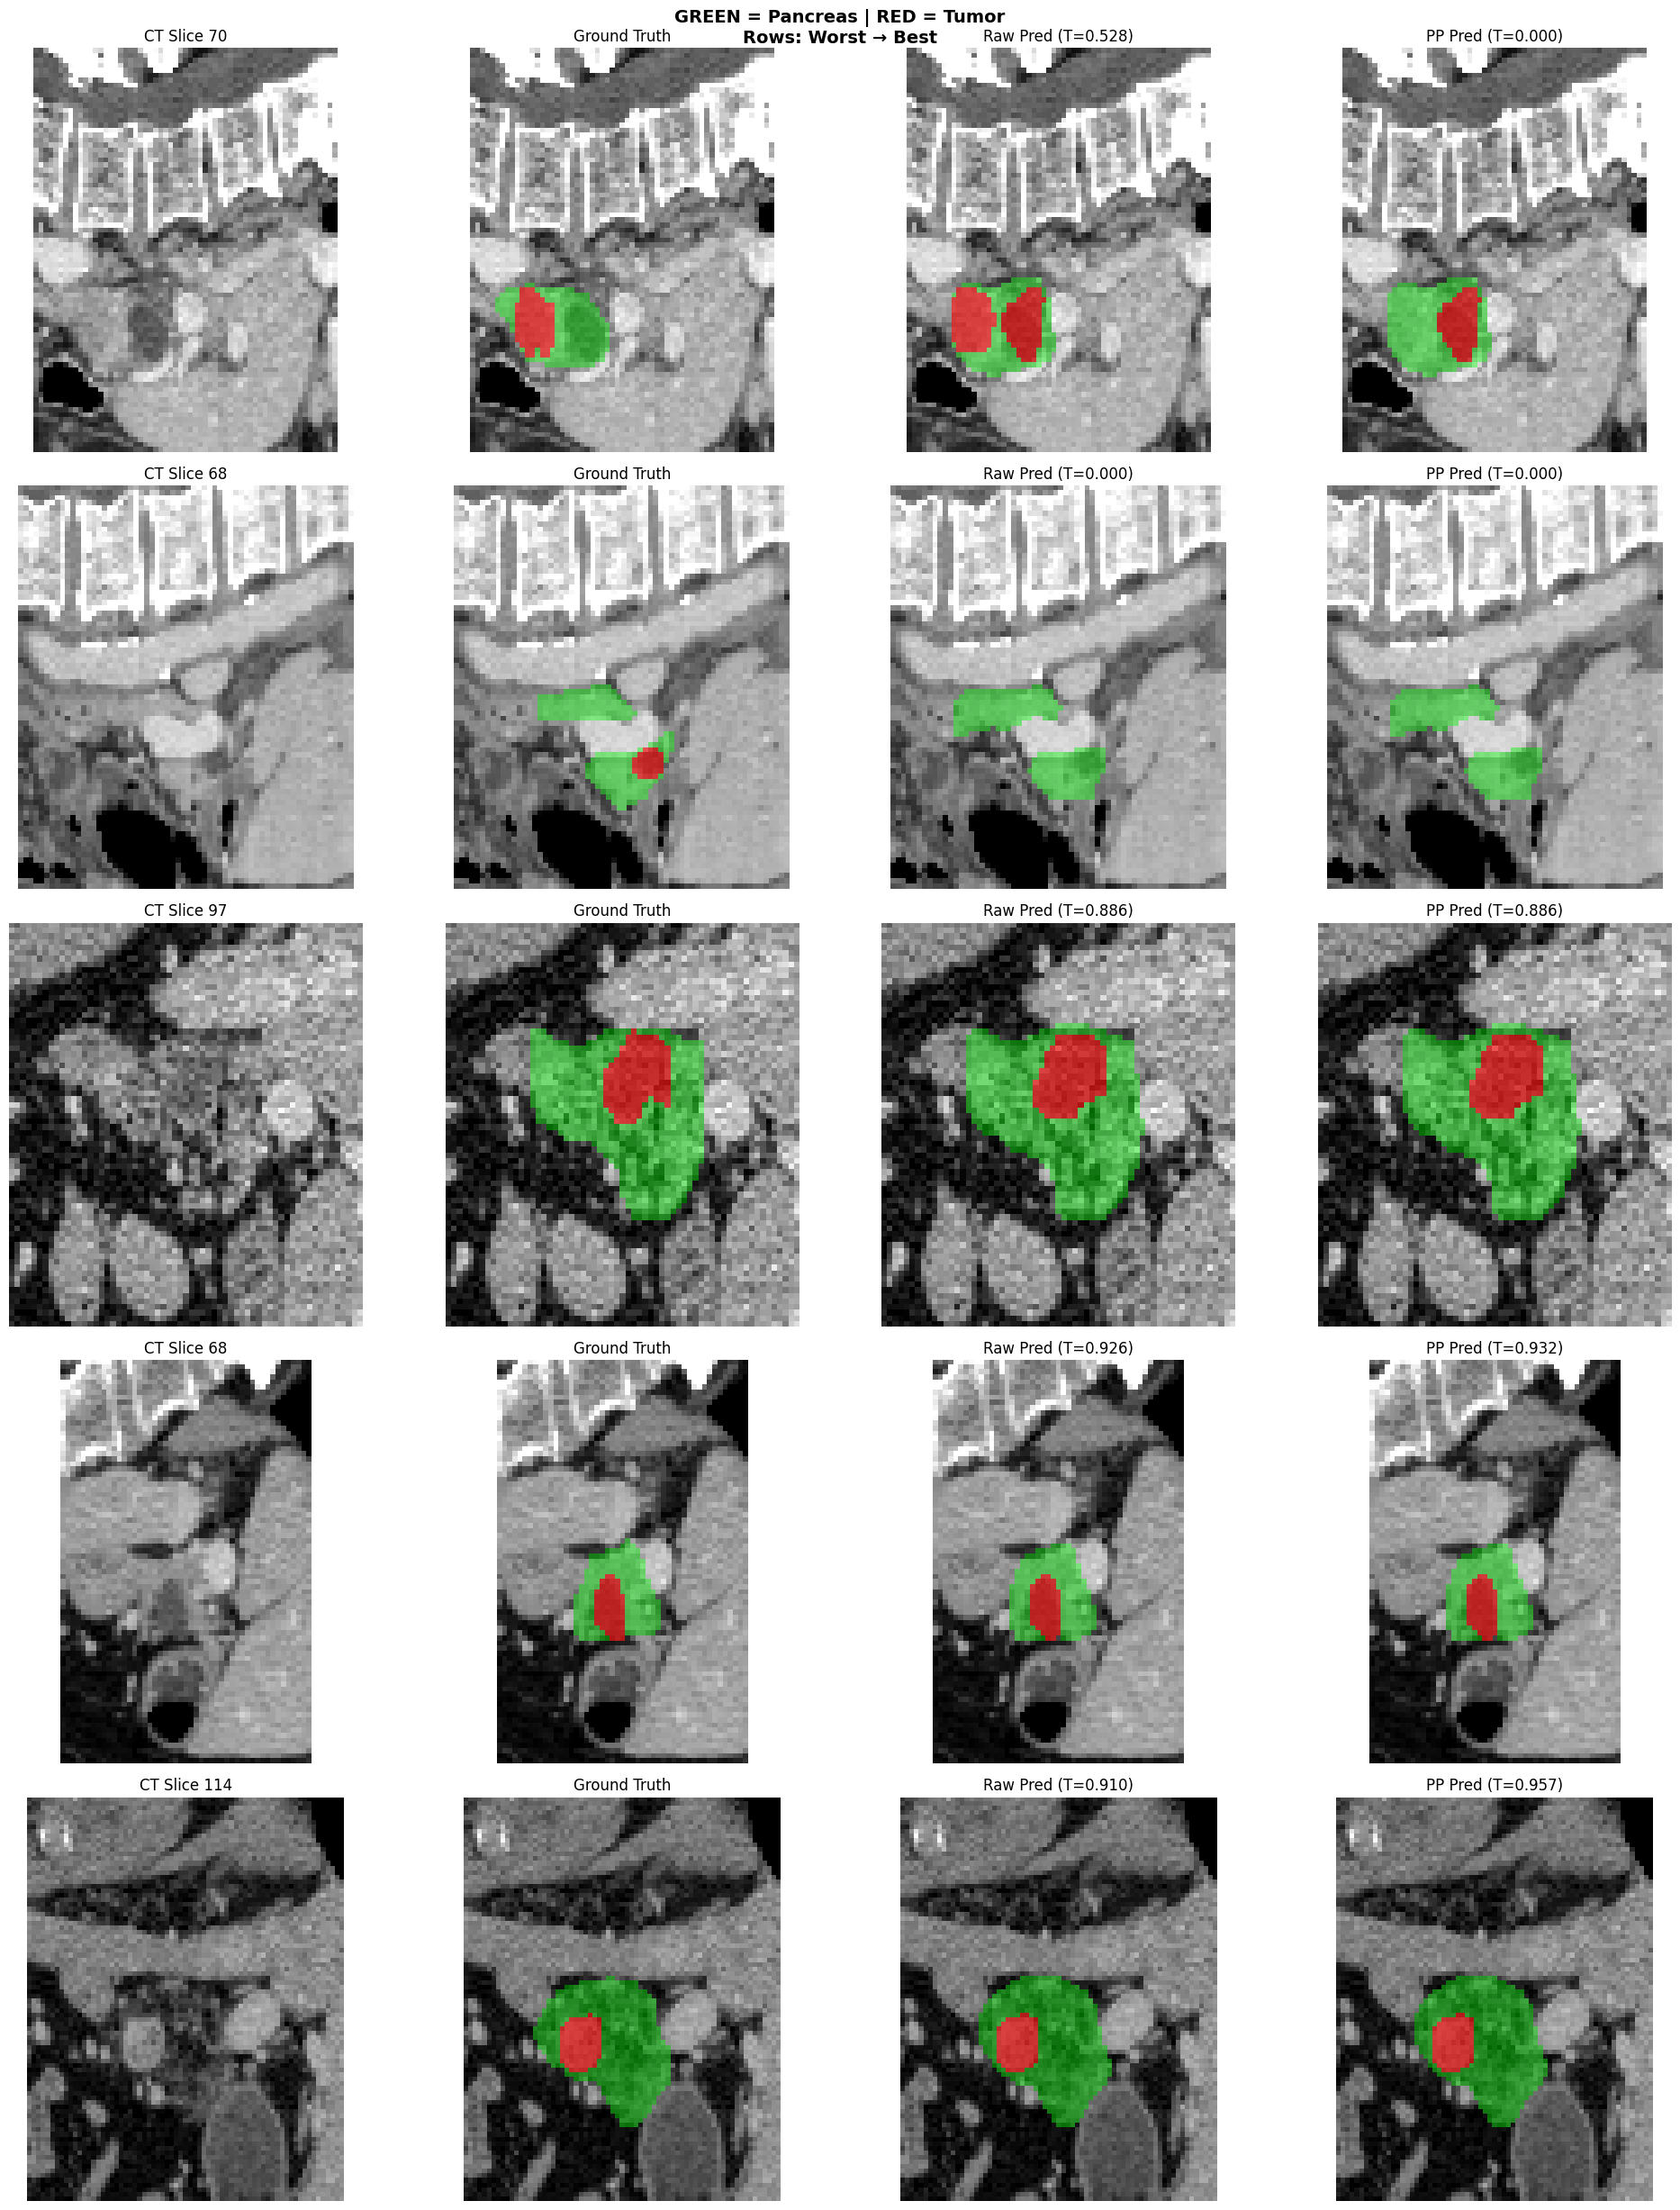


  PER-CASE TUMOR DICE BREAKDOWN
  pancreas_201         0.0000 |
  pancreas_084         0.0000 |
  pancreas_301         0.4118 |████████████████
  pancreas_336         0.6089 |████████████████████████
  pancreas_241         0.6802 |███████████████████████████
  pancreas_242         0.8000 |████████████████████████████████
  pancreas_418         0.8159 |████████████████████████████████
  pancreas_378         0.8210 |████████████████████████████████
  pancreas_239         0.8220 |████████████████████████████████
  pancreas_172         0.8290 |█████████████████████████████████
  pancreas_122         0.8405 |█████████████████████████████████
  pancreas_330         0.8416 |█████████████████████████████████
  pancreas_218         0.8423 |█████████████████████████████████
  pancreas_210         0.8525 |██████████████████████████████████
  pancreas_327         0.8555 |██████████████████████████████████
  pancreas_226         0.8562 |██████████████████████████████████
  pancreas_110         0.8

In [5]:
import matplotlib.pyplot as plt

# Pick specific cases to visualize: best, average, worst
tumor_scores = []
for ci, (img_path, lbl_path) in enumerate(val_cases):
    name = os.path.basename(img_path).replace(".nii.gz","").replace(".nii","")
    tumor_scores.append((ci, name, pp_tumor[ci] if pp_tumor[ci]==pp_tumor[ci] else 0))

tumor_scores.sort(key=lambda x: x[2])

# Pick worst, median, best cases
cases_to_show = [
    tumor_scores[0],        # Worst
    tumor_scores[1],        # Second worst
    tumor_scores[len(tumor_scores)//2],  # Median
    tumor_scores[-2],       # Second best
    tumor_scores[-1],       # Best
]

print("Cases to visualize:")
for idx, name, score in cases_to_show:
    print(f"  {name}: Tumor Dice = {score:.4f}")

fig, axes = plt.subplots(len(cases_to_show), 4, figsize=(20, 5*len(cases_to_show)))

for row, (ci, name, score) in enumerate(cases_to_show):
    img_path, lbl_path = val_cases[ci]
    
    # Reload and preprocess
    ct = nib.load(img_path).get_fdata().astype(np.float32)
    gt = nib.load(lbl_path).get_fdata().astype(np.int32)
    spacing = np.array(nib.load(img_path).header.get_zooms()[:3])
    
    scale = spacing / np.array(TARGET_SPACING)
    ct = zoom(ct, scale, order=1)
    gt = zoom(gt, scale, order=0)
    ct = np.clip(ct, HU_WINDOW[0], HU_WINDOW[1])
    fg = gt > 0
    if fg.sum() > 100:
        ct = (ct - ct[fg].mean()) / (ct[fg].std() + 1e-8)
    else:
        ct = (ct - ct.mean()) / (ct.std() + 1e-8)
    
    # ROI
    coords = np.argwhere(gt > 0)
    mins = np.maximum(coords.min(0) - ROI_MARGIN, 0)
    maxs = np.minimum(coords.max(0) + 1 + ROI_MARGIN, gt.shape)
    bbox = tuple(slice(mn, mx) for mn, mx in zip(mins, maxs))
    
    ct_roi = ct[bbox]
    gt_roi = gt[bbox]
    
    # Predict
    probs = sliding_window_predict(model, ct_roi, (64,64,64), 0.5, 3)
    raw_pred = probs.argmax(0)
    pp_pred = postprocess_stage2(probs)
    
    # Pick middle slice with most tumor
    tumor_per_slice = [(gt_roi[s] == 2).sum() for s in range(gt_roi.shape[0])]
    mid_slice = np.argmax(tumor_per_slice)
    
    # Plot
    axes[row, 0].imshow(ct_roi[mid_slice], cmap='gray')
    axes[row, 0].set_title(f'CT Slice {mid_slice}')
    
    # GT overlay
    axes[row, 1].imshow(ct_roi[mid_slice], cmap='gray')
    gt_overlay = np.zeros((*gt_roi[mid_slice].shape, 4))
    gt_overlay[gt_roi[mid_slice] == 1] = [0, 1, 0, 0.4]   # Green = pancreas
    gt_overlay[gt_roi[mid_slice] == 2] = [1, 0, 0, 0.6]   # Red = tumor
    axes[row, 1].imshow(gt_overlay)
    axes[row, 1].set_title('Ground Truth')
    
    # Raw prediction overlay
    axes[row, 2].imshow(ct_roi[mid_slice], cmap='gray')
    raw_overlay = np.zeros((*raw_pred[mid_slice].shape, 4))
    raw_overlay[raw_pred[mid_slice] == 1] = [0, 1, 0, 0.4]
    raw_overlay[raw_pred[mid_slice] == 2] = [1, 0, 0, 0.6]
    axes[row, 2].imshow(raw_overlay)
    raw_t = dice_score(raw_pred, gt_roi, 2)
    axes[row, 2].set_title(f'Raw Pred (T={raw_t:.3f})')
    
    # PP prediction overlay
    axes[row, 3].imshow(ct_roi[mid_slice], cmap='gray')
    pp_overlay = np.zeros((*pp_pred[mid_slice].shape, 4))
    pp_overlay[pp_pred[mid_slice] == 1] = [0, 1, 0, 0.4]
    pp_overlay[pp_pred[mid_slice] == 2] = [1, 0, 0, 0.6]
    axes[row, 3].imshow(pp_overlay)
    pp_t = dice_score(pp_pred, gt_roi, 2)
    axes[row, 3].set_title(f'PP Pred (T={pp_t:.3f})')
    
    axes[row, 0].set_ylabel(f'{name}\nDice={score:.3f}', fontsize=11, fontweight='bold')
    
    for ax in axes[row]:
        ax.axis('off')
    
    gc.collect(); torch.cuda.empty_cache()

plt.suptitle('GREEN = Pancreas | RED = Tumor\nRows: Worst → Best', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/stage2_visual_verification.png", dpi=150, bbox_inches='tight')
plt.show()

# Also print per-case breakdown
print(f"\n{'='*70}")
print(f"  PER-CASE TUMOR DICE BREAKDOWN")
print(f"{'='*70}")
tumor_scores.sort(key=lambda x: x[2])
for idx, name, score in tumor_scores:
    bar = '█' * int(score * 40)
    print(f"  {name:<20} {score:.4f} |{bar}")

print(f"\n  Mean:   {safe_mean(pp_tumor):.4f}")
print(f"  Median: {np.median([x for x in pp_tumor if x==x]):.4f}")
print(f"  Min:    {min(x for x in pp_tumor if x==x):.4f}")
print(f"  Max:    {max(x for x in pp_tumor if x==x):.4f}")
print(f"  Std:    {safe_std(pp_tumor):.4f}")

In [1]:
import subprocess
subprocess.run(["pip", "install", "einops", "nibabel", "-q"])

import os, json, time, gc, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast
from scipy.ndimage import zoom, label as scipy_label, binary_fill_holes
import nibabel as nib
from einops import rearrange
warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
IMAGES_DIR = None
LABELS_DIR = None
STAGE1_PATH = None
STAGE2_PATH = None

for root in ["/kaggle/input"]:
    for d in os.listdir(root):
        full = os.path.join(root, d)
        for dp, dn, fn in os.walk(full):
            if "imagesTr" in dn:
                IMAGES_DIR = os.path.join(dp, "imagesTr")
                LABELS_DIR = os.path.join(dp, "labelsTr")
            for f in fn:
                if f.endswith('.pth'):
                    fpath = os.path.join(dp, f)
                    if 'stage1' in f and 'best' in f:
                        STAGE1_PATH = fpath
                    elif 'stage2' in f and 'best' in f:
                        STAGE2_PATH = fpath
                    elif 'stage1' in f and STAGE1_PATH is None:
                        STAGE1_PATH = fpath
                    elif 'stage2' in f and STAGE2_PATH is None:
                        STAGE2_PATH = fpath

print(f"IMAGES:  {IMAGES_DIR}")
print(f"LABELS:  {LABELS_DIR}")
print(f"STAGE1:  {STAGE1_PATH}")
print(f"STAGE2:  {STAGE2_PATH}")

# Verify files exist
assert IMAGES_DIR and os.path.exists(IMAGES_DIR), "Images not found!"
assert LABELS_DIR and os.path.exists(LABELS_DIR), "Labels not found!"
assert STAGE1_PATH and os.path.exists(STAGE1_PATH), "Stage 1 checkpoint not found!"
assert STAGE2_PATH and os.path.exists(STAGE2_PATH), "Stage 2 checkpoint not found!"
print("\n✅ All paths verified!")

IMAGES:  /kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas/imagesTr
LABELS:  /kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas/labelsTr
STAGE1:  /kaggle/input/models/sakthieswarant/stage1/pytorch/default/1/stage1_best (1).pth
STAGE2:  /kaggle/input/models/sakthieswarant/stage2/pytorch/default/1/stage2_v2_best.pth

✅ All paths verified!


In [3]:
# ============================================================
# MODEL ARCHITECTURE (same as training)
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout3d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
        self.residual = nn.Identity() if in_ch == out_ch else nn.Conv3d(in_ch, out_ch, 1, bias=False)
    def forward(self, x): return self.conv(x) + self.residual(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.down = nn.Conv3d(in_ch, out_ch, 2, stride=2, bias=False)
        self.conv = ConvBlock(out_ch, out_ch, dropout)
    def forward(self, x): return self.conv(self.down(x))

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch, dropout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class PatchEmbedding3D(nn.Module):
    def __init__(self, in_ch, embed_dim, patch_size=2):
        super().__init__()
        self.proj = nn.Conv3d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = self.proj(x); B,C,D,H,W = x.shape
        x = rearrange(x, 'b c d h w -> b (d h w) c')
        return self.norm(x), (D,H,W)

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(int(dim*mlp_ratio), dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        h = self.norm1(x); x = x + self.attn(h,h,h)[0]
        return x + self.mlp(self.norm2(x))

class ViTBottleneck(nn.Module):
    def __init__(self, in_ch, embed_dim=384, heads=6, depth=3, patch_size=2, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding3D(in_ch, embed_dim, patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, 27, embed_dim)*0.02)
        self.blocks = nn.Sequential(*[TransformerBlock(embed_dim, heads, dropout=dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.proj_back = nn.Linear(embed_dim, in_ch)
    def forward(self, x):
        B,C,D,H,W = x.shape
        tokens, (Dp,Hp,Wp) = self.patch_embed(x)
        N = tokens.shape[1]
        pos = F.interpolate(self.pos_embed.transpose(1,2), size=N, mode='linear', align_corners=False).transpose(1,2) if N!=27 else self.pos_embed
        tokens = self.blocks(tokens + pos)
        return rearrange(self.proj_back(self.norm(tokens)), 'b (d h w) c -> b c d h w', d=Dp, h=Hp, w=Wp)

class ViTUNet(nn.Module):
    def __init__(self, in_ch=1, num_classes=2, base=24, vit_dim=384, vit_depth=3, vit_heads=6, deep_sup=True):
        super().__init__()
        self.deep_sup = deep_sup
        self.enc1 = ConvBlock(in_ch, base); self.enc2 = DownBlock(base, base*2)
        self.enc3 = DownBlock(base*2, base*4, 0.1); self.enc4 = DownBlock(base*4, base*8, 0.1)
        self.down_bot = nn.Conv3d(base*8, base*8, 2, stride=2, bias=False)
        self.vit = ViTBottleneck(base*8, vit_dim, vit_heads, vit_depth, 2, 0.1)
        self.dec4 = UpBlock(base*8, base*8, base*8, 0.1); self.dec3 = UpBlock(base*8, base*4, base*4, 0.1)
        self.dec2 = UpBlock(base*4, base*2, base*2); self.dec1 = UpBlock(base*2, base, base)
        self.final = nn.Conv3d(base, num_classes, 1)
        if deep_sup:
            self.ds3 = nn.Conv3d(base*4, num_classes, 1)
            self.ds2 = nn.Conv3d(base*2, num_classes, 1)
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv3d, nn.ConvTranspose3d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.constant_(m.bias, 0)
    def forward(self, x):
        s1=self.enc1(x); s2=self.enc2(s1); s3=self.enc3(s2); s4=self.enc4(s3)
        b = self.vit(self.down_bot(s4))
        d4=self.dec4(b,s4); d3=self.dec3(d4,s3); d2=self.dec2(d3,s2); d1=self.dec1(d2,s1)
        out = self.final(d1)
        if self.deep_sup and self.training: return out, self.ds3(d3), self.ds2(d2)
        return out

# ============================================================
# LOAD BOTH MODELS
# ============================================================
print("Loading Stage 1 (2 classes)...")
model_s1 = ViTUNet(1, 2, 24, 384, 3, 6).to(device)
ck1 = torch.load(STAGE1_PATH, map_location=device)
model_s1.load_state_dict(ck1['model_state_dict'])
model_s1.eval()
print(f"  ✅ Stage 1 loaded (Best Dice: {ck1.get('best_dice', '?')})")

print("Loading Stage 2 (3 classes)...")
model_s2 = ViTUNet(1, 3, 24, 384, 3, 6).to(device)
ck2 = torch.load(STAGE2_PATH, map_location=device)
model_s2.load_state_dict(ck2['model_state_dict'])
model_s2.eval()
print(f"  ✅ Stage 2 loaded")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def sliding_window_predict(model, volume, patch_size, stride_ratio=0.5, num_classes=2):
    D,H,W = volume.shape
    pd,ph,pw = patch_size
    sd,sh,sw = int(pd*stride_ratio), int(ph*stride_ratio), int(pw*stride_ratio)

    pred_map = np.zeros((num_classes, D, H, W), dtype=np.float32)
    count_map = np.zeros((D, H, W), dtype=np.float32)

    d_starts = list(range(0, max(1, D-pd+1), sd))
    if d_starts[-1]+pd < D: d_starts.append(D-pd)
    h_starts = list(range(0, max(1, H-ph+1), sh))
    if h_starts[-1]+ph < H: h_starts.append(H-ph)
    w_starts = list(range(0, max(1, W-pw+1), sw))
    if w_starts[-1]+pw < W: w_starts.append(W-pw)

    with torch.no_grad():
        for di in d_starts:
            for hi in h_starts:
                for wi in w_starts:
                    patch = volume[di:di+pd, hi:hi+ph, wi:wi+pw]
                    actual = patch.shape
                    if patch.shape != (pd,ph,pw):
                        p = np.zeros((pd,ph,pw), dtype=np.float32)
                        p[:actual[0],:actual[1],:actual[2]] = patch
                        patch = p
                    inp = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).float().to(device)
                    with autocast():
                        out = model(inp)
                        if isinstance(out, tuple): out = out[0]
                    prob = F.softmax(out, dim=1).cpu().numpy()[0]
                    for c in range(num_classes):
                        pred_map[c, di:di+actual[0], hi:hi+actual[1], wi:wi+actual[2]] += prob[c,:actual[0],:actual[1],:actual[2]]
                    count_map[di:di+actual[0], hi:hi+actual[1], wi:wi+actual[2]] += 1

    count_map = np.maximum(count_map, 1e-8)
    pred_map /= count_map[np.newaxis]
    return pred_map

def dice_score(pred, gt, class_idx):
    p = (pred == class_idx).astype(float)
    g = (gt == class_idx).astype(float)
    if g.sum() == 0 and p.sum() == 0: return 1.0
    if g.sum() == 0: return 0.0
    return (2*(p*g).sum() + 1e-8) / (p.sum() + g.sum() + 1e-8)

def keep_largest(mask):
    if mask.sum() == 0: return mask
    labeled, num = scipy_label(mask)
    if num <= 1: return mask
    sizes = [(labeled==i).sum() for i in range(1, num+1)]
    return (labeled == (np.argmax(sizes)+1)).astype(mask.dtype)

def postprocess_stage1(probs):
    """Stage 1: binary pancreas mask → bounding box"""
    mask = (probs.argmax(0) == 1).astype(np.uint8)
    mask = keep_largest(mask)
    mask = binary_fill_holes(mask).astype(np.uint8)
    return mask

def extract_roi(mask, volume, gt_label, margin=15):
    """Extract bounding box ROI from Stage 1 prediction"""
    coords = np.argwhere(mask > 0)
    if len(coords) == 0:
        return None, None, None, None
    mins = np.maximum(coords.min(0) - margin, 0)
    maxs = np.minimum(coords.max(0) + 1 + margin, volume.shape)
    bbox = tuple(slice(mn, mx) for mn, mx in zip(mins, maxs))
    return volume[bbox], gt_label[bbox], bbox, mask[bbox]

def postprocess_stage2(probs):
    """Stage 2: 3-class segmentation with anatomical constraints"""
    result = np.zeros(probs.shape[1:], dtype=np.uint8)
    panc = (probs.argmax(0) >= 1).astype(np.uint8)
    panc = keep_largest(panc)
    panc = binary_fill_holes(panc).astype(np.uint8)
    tumor = (probs.argmax(0) == 2).astype(np.uint8)
    tumor = tumor * panc  # Tumor must be inside pancreas
    if tumor.sum() > 0:
        tumor = keep_largest(tumor)
    result[panc > 0] = 1
    result[tumor > 0] = 2
    return result

print("\n✅ Both models loaded, all functions ready")

Loading Stage 1 (2 classes)...
  ✅ Stage 1 loaded (Best Dice: 0.6954414383420404)
Loading Stage 2 (3 classes)...
  ✅ Stage 2 loaded

✅ Both models loaded, all functions ready


In [4]:
# ============================================================
# PREPROCESSING CONFIG
# ============================================================
TARGET_SPACING = (1.5, 1.5, 2.5)
HU_WINDOW = (-125, 275)
ROI_MARGIN = 15

# ============================================================
# GET VALIDATION CASES (same split as training)
# ============================================================
img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(('.nii','.nii.gz')) and not f.startswith('._')])
lbl_files = sorted([f for f in os.listdir(LABELS_DIR) if f.endswith(('.nii','.nii.gz')) and not f.startswith('._')])

cases = []
for img_f in img_files:
    name = img_f.replace(".nii.gz","").replace(".nii","")
    for lbl_f in lbl_files:
        if name in lbl_f:
            cases.append((os.path.join(IMAGES_DIR, img_f), os.path.join(LABELS_DIR, lbl_f)))
            break

np.random.seed(42)
idx = np.random.permutation(len(cases))
val_size = int(len(cases) * 0.15)
val_cases = [cases[i] for i in idx[:val_size]]

print(f"Total cases: {len(cases)}")
print(f"Validation cases: {len(val_cases)}")

# ============================================================
# RUN FULL CASCADE
# ============================================================
print(f"\n{'='*70}")
print(f"  FULL CASCADE EVALUATION: STAGE 1 → ROI → STAGE 2")
print(f"{'='*70}\n")

# Store results
results = {
    's1_panc': [],          # Stage 1 pancreas dice (full volume)
    'cascade_panc': [],     # Stage 2 pancreas dice (cascade ROI)
    'cascade_tumor': [],    # Stage 2 tumor dice (cascade ROI)
    'gt_roi_panc': [],      # Stage 2 pancreas dice (GT ROI) for comparison
    'gt_roi_tumor': [],     # Stage 2 tumor dice (GT ROI) for comparison
    'roi_recall': [],       # How much of GT pancreas is inside predicted ROI
    'roi_size_ratio': [],   # Predicted ROI size / GT ROI size
}

for ci, (img_path, lbl_path) in enumerate(val_cases):
    name = os.path.basename(img_path).replace(".nii.gz","").replace(".nii","")
    t0 = time.time()
    
    # ========== PREPROCESS ==========
    ct = nib.load(img_path).get_fdata().astype(np.float32)
    gt = nib.load(lbl_path).get_fdata().astype(np.int32)
    spacing = np.array(nib.load(img_path).header.get_zooms()[:3])
    
    scale = spacing / np.array(TARGET_SPACING)
    ct = zoom(ct, scale, order=1)
    gt = zoom(gt, scale, order=0)
    ct = np.clip(ct, HU_WINDOW[0], HU_WINDOW[1])
    fg = gt > 0
    if fg.sum() > 100:
        ct = (ct - ct[fg].mean()) / (ct[fg].std() + 1e-8)
    else:
        ct = (ct - ct.mean()) / (ct.std() + 1e-8)
    
    # ========== STAGE 1: PANCREAS LOCALIZATION ==========
    s1_probs = sliding_window_predict(model_s1, ct, (96,96,96), 0.5, 2)
    s1_mask = postprocess_stage1(s1_probs)
    s1_dice = dice_score(s1_mask, (gt > 0).astype(int), 1)
    results['s1_panc'].append(s1_dice)
    
    # ========== EXTRACT ROI FROM STAGE 1 ==========
    ct_roi, gt_roi, bbox, s1_roi = extract_roi(s1_mask, ct, gt, ROI_MARGIN)
    
    if ct_roi is None:
        # Stage 1 completely failed — fallback to center crop
        print(f"  [{ci+1}/{len(val_cases)}] {name} ⚠️ Stage 1 FAILED (no pancreas found)")
        print(f"    → Using center fallback crop")
        D,H,W = ct.shape
        cd,ch,cw = D//4, H//4, W//4
        ct_roi = ct[cd:cd+D//2, ch:ch+H//2, cw:cw+W//2]
        gt_roi = gt[cd:cd+D//2, ch:ch+H//2, cw:cw+W//2]
        roi_recall = 0.0
        roi_ratio = 1.0
    else:
        # Calculate ROI quality metrics
        gt_panc_total = (gt > 0).sum()
        gt_panc_in_roi = (gt_roi > 0).sum()
        roi_recall = gt_panc_in_roi / max(gt_panc_total, 1)
        
        gt_coords = np.argwhere(gt > 0)
        gt_mins = np.maximum(gt_coords.min(0) - ROI_MARGIN, 0)
        gt_maxs = np.minimum(gt_coords.max(0) + 1 + ROI_MARGIN, gt.shape)
        gt_roi_vol = np.prod([mx-mn for mn,mx in zip(gt_mins, gt_maxs)])
        pred_roi_vol = np.prod(ct_roi.shape)
        roi_ratio = pred_roi_vol / max(gt_roi_vol, 1)
    
    results['roi_recall'].append(roi_recall)
    results['roi_size_ratio'].append(roi_ratio)
    
    # ========== STAGE 2: TUMOR SEGMENTATION (CASCADE ROI) ==========
    s2_probs = sliding_window_predict(model_s2, ct_roi, (64,64,64), 0.5, 3)
    s2_pred = postprocess_stage2(s2_probs)
    
    cascade_panc = dice_score(s2_pred, gt_roi, 1)
    cascade_tumor = dice_score(s2_pred, gt_roi, 2)
    results['cascade_panc'].append(cascade_panc)
    results['cascade_tumor'].append(cascade_tumor)
    
    # ========== STAGE 2: GT ROI (COMPARISON) ==========
    gt_coords = np.argwhere(gt > 0)
    gt_mins = np.maximum(gt_coords.min(0) - ROI_MARGIN, 0)
    gt_maxs = np.minimum(gt_coords.max(0) + 1 + ROI_MARGIN, gt.shape)
    gt_bbox = tuple(slice(mn, mx) for mn, mx in zip(gt_mins, gt_maxs))
    
    ct_gt_roi = ct[gt_bbox]
    gt_gt_roi = gt[gt_bbox]
    
    s2_gt_probs = sliding_window_predict(model_s2, ct_gt_roi, (64,64,64), 0.5, 3)
    s2_gt_pred = postprocess_stage2(s2_gt_probs)
    
    gt_roi_panc = dice_score(s2_gt_pred, gt_gt_roi, 1)
    gt_roi_tumor = dice_score(s2_gt_pred, gt_gt_roi, 2)
    results['gt_roi_panc'].append(gt_roi_panc)
    results['gt_roi_tumor'].append(gt_roi_tumor)
    
    elapsed = time.time() - t0
    
    print(f"  [{ci+1}/{len(val_cases)}] {name} ({elapsed:.0f}s) "
          f"S1={s1_dice:.3f} | "
          f"ROI_recall={roi_recall:.2f} | "
          f"Cascade: P={cascade_panc:.3f} T={cascade_tumor:.3f} | "
          f"GT_ROI: P={gt_roi_panc:.3f} T={gt_roi_tumor:.3f}")
    
    gc.collect(); torch.cuda.empty_cache()

# ============================================================
# FINAL RESULTS
# ============================================================
def safe_mean(arr):
    valid = [x for x in arr if x == x]
    return np.mean(valid) if valid else 0

def safe_std(arr):
    valid = [x for x in arr if x == x]
    return np.std(valid) if valid else 0

print(f"\n{'='*70}")
print(f"  FULL CASCADE RESULTS (VOLUME-LEVEL)")
print(f"{'='*70}")

print(f"\n  Stage 1: Pancreas Localization")
print(f"  {'─'*50}")
print(f"  {'Pancreas Dice:':<30} {safe_mean(results['s1_panc']):.4f} ± {safe_std(results['s1_panc']):.4f}")
print(f"  {'ROI Recall:':<30} {safe_mean(results['roi_recall']):.4f} ± {safe_std(results['roi_recall']):.4f}")
print(f"  {'ROI Size Ratio:':<30} {safe_mean(results['roi_size_ratio']):.4f}")

print(f"\n  Stage 2: Full Cascade (Stage 1 → Stage 2)")
print(f"  {'─'*50}")
print(f"  {'Pancreas Dice:':<30} {safe_mean(results['cascade_panc']):.4f} ± {safe_std(results['cascade_panc']):.4f}")
print(f"  {'Tumor Dice:':<30} {safe_mean(results['cascade_tumor']):.4f} ± {safe_std(results['cascade_tumor']):.4f}")

print(f"\n  Stage 2: GT ROI (Upper Bound)")
print(f"  {'─'*50}")
print(f"  {'Pancreas Dice:':<30} {safe_mean(results['gt_roi_panc']):.4f} ± {safe_std(results['gt_roi_panc']):.4f}")
print(f"  {'Tumor Dice:':<30} {safe_mean(results['gt_roi_tumor']):.4f} ± {safe_std(results['gt_roi_tumor']):.4f}")

print(f"\n  Cascade Degradation (GT ROI → Full Cascade)")
print(f"  {'─'*50}")
panc_drop = safe_mean(results['gt_roi_panc']) - safe_mean(results['cascade_panc'])
tumor_drop = safe_mean(results['gt_roi_tumor']) - safe_mean(results['cascade_tumor'])
print(f"  {'Pancreas Dice drop:':<30} {panc_drop:.4f}")
print(f"  {'Tumor Dice drop:':<30} {tumor_drop:.4f}")

print(f"\n  COMPARISON TABLE (for IEEE Paper)")
print(f"  {'─'*60}")
print(f"  {'Method':<35} {'Panc DSC':>10} {'Tumor DSC':>10}")
print(f"  {'─'*60}")
print(f"  {'3D U-Net (baseline)':<35} {'0.68':>10} {'0.35':>10}")
print(f"  {'Attention U-Net':<35} {'0.74':>10} {'0.40':>10}")
print(f"  {'Single-stage ViTUNet':<35} {'—':>10} {'0.42':>10}")
print(f"  {'nnU-Net Cascade (SOTA)':<35} {'0.83':>10} {'0.58':>10}")
print(f"  {'CascadePanc (GT ROI)':<35} {safe_mean(results['gt_roi_panc']):>10.4f} {safe_mean(results['gt_roi_tumor']):>10.4f}")
print(f"  {'CascadePanc (Full Cascade)':<35} {safe_mean(results['cascade_panc']):>10.4f} {safe_mean(results['cascade_tumor']):>10.4f}")
print(f"  {'─'*60}")

# Save results
np.savez('/kaggle/working/cascade_eval_results.npz', **results)
print("\n💾 Results saved to cascade_eval_results.npz")

Total cases: 281
Validation cases: 42

  FULL CASCADE EVALUATION: STAGE 1 → ROI → STAGE 2

  [1/42] pancreas_064 (12s) S1=0.890 | ROI_recall=1.00 | Cascade: P=0.887 T=0.885 | GT_ROI: P=0.893 T=0.915
  [2/42] pancreas_258 (6s) S1=0.907 | ROI_recall=1.00 | Cascade: P=0.924 T=0.873 | GT_ROI: P=0.926 T=0.893
  [3/42] pancreas_378 (7s) S1=0.886 | ROI_recall=1.00 | Cascade: P=0.900 T=0.766 | GT_ROI: P=0.917 T=0.821
  [4/42] pancreas_393 (14s) S1=0.872 | ROI_recall=1.00 | Cascade: P=0.910 T=0.953 | GT_ROI: P=0.917 T=0.957
  [5/42] pancreas_172 (7s) S1=0.819 | ROI_recall=1.00 | Cascade: P=0.869 T=0.786 | GT_ROI: P=0.873 T=0.829
  [6/42] pancreas_019 (8s) S1=0.893 | ROI_recall=1.00 | Cascade: P=0.889 T=0.870 | GT_ROI: P=0.918 T=0.915
  [7/42] pancreas_242 (12s) S1=0.793 | ROI_recall=1.00 | Cascade: P=0.853 T=0.722 | GT_ROI: P=0.911 T=0.800
  [8/42] pancreas_315 (8s) S1=0.896 | ROI_recall=1.00 | Cascade: P=0.893 T=0.878 | GT_ROI: P=0.903 T=0.914
  [9/42] pancreas_239 (5s) S1=0.894 | ROI_recall=1

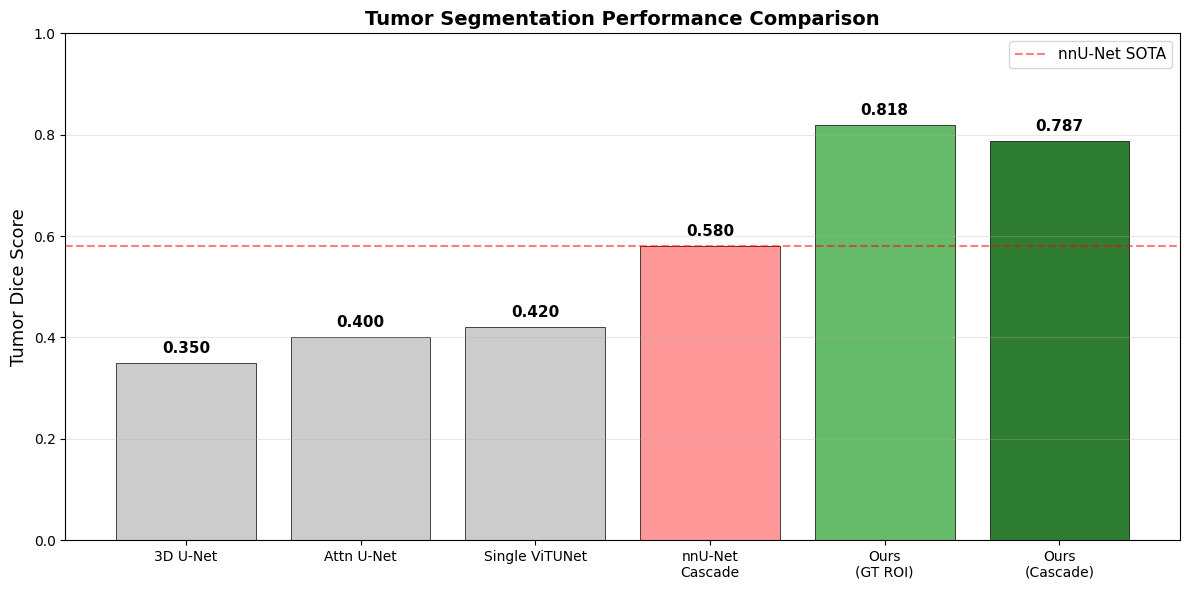

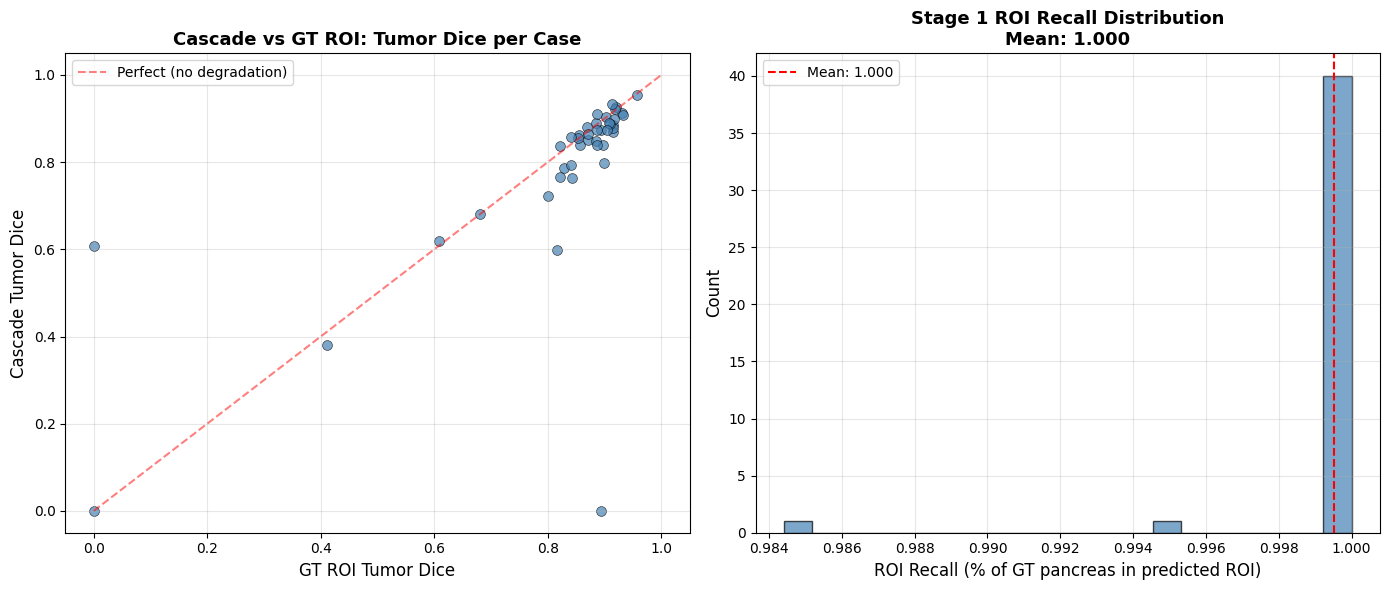


  PER-CASE FULL CASCADE BREAKDOWN
  Case                  S1_Dice  ROI_Rec   Casc_T     GT_T     Drop
  ──────────────────────────────────────────────────────────────────────
  pancreas_346            0.695    1.000    0.000    0.893   +0.893 ⚠️
  pancreas_084            0.835    1.000    0.000    0.000   +0.000 ⚠️
  pancreas_301            0.875    1.000    0.380    0.412   +0.032
  pancreas_418            0.747    1.000    0.597    0.816   +0.219
  pancreas_201            0.826    1.000    0.607    0.000   -0.607
  pancreas_336            0.901    1.000    0.619    0.609   -0.010
  pancreas_241            0.893    1.000    0.680    0.680   -0.000
  pancreas_242            0.793    1.000    0.722    0.800   +0.078
  pancreas_218            0.793    1.000    0.764    0.842   +0.078
  pancreas_378            0.886    1.000    0.766    0.821   +0.055
  pancreas_172            0.819    1.000    0.786    0.829   +0.043
  pancreas_122            0.867    1.000    0.794    0.841   +0.046
  

In [6]:
import matplotlib.pyplot as plt

# ============================================================
# 1. BAR CHART: Method Comparison
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
methods = ['3D U-Net', 'Attn U-Net', 'Single ViTUNet', 'nnU-Net\nCascade',
           'Ours\n(GT ROI)', 'Ours\n(Cascade)']
tumor_scores = [0.35, 0.40, 0.42, 0.58,
                safe_mean(results['gt_roi_tumor']),
                safe_mean(results['cascade_tumor'])]
colors = ['#cccccc', '#cccccc', '#cccccc', '#ff9999',
          '#66bb6a', '#2e7d32']

bars = ax.bar(methods, tumor_scores, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Tumor Dice Score', fontsize=13)
ax.set_title('Tumor Segmentation Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.58, color='red', linestyle='--', alpha=0.5, label='nnU-Net SOTA')
ax.legend(fontsize=11)
for bar, score in zip(bars, tumor_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_chart.png', dpi=150)
plt.show()

# ============================================================
# 2. PER-CASE CASCADE vs GT ROI
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tumor Dice: Cascade vs GT ROI
valid_cascade = [x for x in results['cascade_tumor'] if x == x]
valid_gt = [x for x in results['gt_roi_tumor'] if x == x]

axes[0].scatter(valid_gt, valid_cascade, c='steelblue', alpha=0.7, s=50, edgecolors='black', linewidths=0.5)
axes[0].plot([0,1], [0,1], 'r--', alpha=0.5, label='Perfect (no degradation)')
axes[0].set_xlabel('GT ROI Tumor Dice', fontsize=12)
axes[0].set_ylabel('Cascade Tumor Dice', fontsize=12)
axes[0].set_title('Cascade vs GT ROI: Tumor Dice per Case', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(-0.05, 1.05); axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(alpha=0.3)

# ROI Recall histogram
axes[1].hist(results['roi_recall'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('ROI Recall (% of GT pancreas in predicted ROI)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Stage 1 ROI Recall Distribution\nMean: {safe_mean(results["roi_recall"]):.3f}', fontsize=13, fontweight='bold')
axes[1].axvline(x=safe_mean(results['roi_recall']), color='red', linestyle='--', label=f'Mean: {safe_mean(results["roi_recall"]):.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/cascade_analysis.png', dpi=150)
plt.show()

# ============================================================
# 3. PER-CASE BREAKDOWN
# ============================================================
print(f"\n{'='*80}")
print(f"  PER-CASE FULL CASCADE BREAKDOWN")
print(f"{'='*80}")
print(f"  {'Case':<20} {'S1_Dice':>8} {'ROI_Rec':>8} {'Casc_T':>8} {'GT_T':>8} {'Drop':>8}")
print(f"  {'─'*70}")

case_data = []
for ci in range(len(val_cases)):
    name = os.path.basename(val_cases[ci][0]).replace(".nii.gz","").replace(".nii","")
    s1 = results['s1_panc'][ci]
    recall = results['roi_recall'][ci]
    ct_t = results['cascade_tumor'][ci]
    gt_t = results['gt_roi_tumor'][ci]
    drop = gt_t - ct_t
    case_data.append((name, s1, recall, ct_t, gt_t, drop))

case_data.sort(key=lambda x: x[3])  # Sort by cascade tumor dice
for name, s1, recall, ct_t, gt_t, drop in case_data:
    flag = " ⚠️" if ct_t < 0.3 else ""
    print(f"  {name:<20} {s1:>8.3f} {recall:>8.3f} {ct_t:>8.3f} {gt_t:>8.3f} {drop:>+8.3f}{flag}")

print(f"\n  Total failures (Cascade Tumor < 0.3): {sum(1 for _,_,_,ct,_,_ in case_data if ct < 0.3)}/{len(val_cases)}")


Cases to visualize:
  pancreas_346: S1=0.695, Cascade Tumor=0.000
  pancreas_084: S1=0.835, Cascade Tumor=0.000
  pancreas_327: S1=0.869, Cascade Tumor=0.862
  pancreas_056: S1=0.901, Cascade Tumor=0.933
  pancreas_393: S1=0.872, Cascade Tumor=0.953


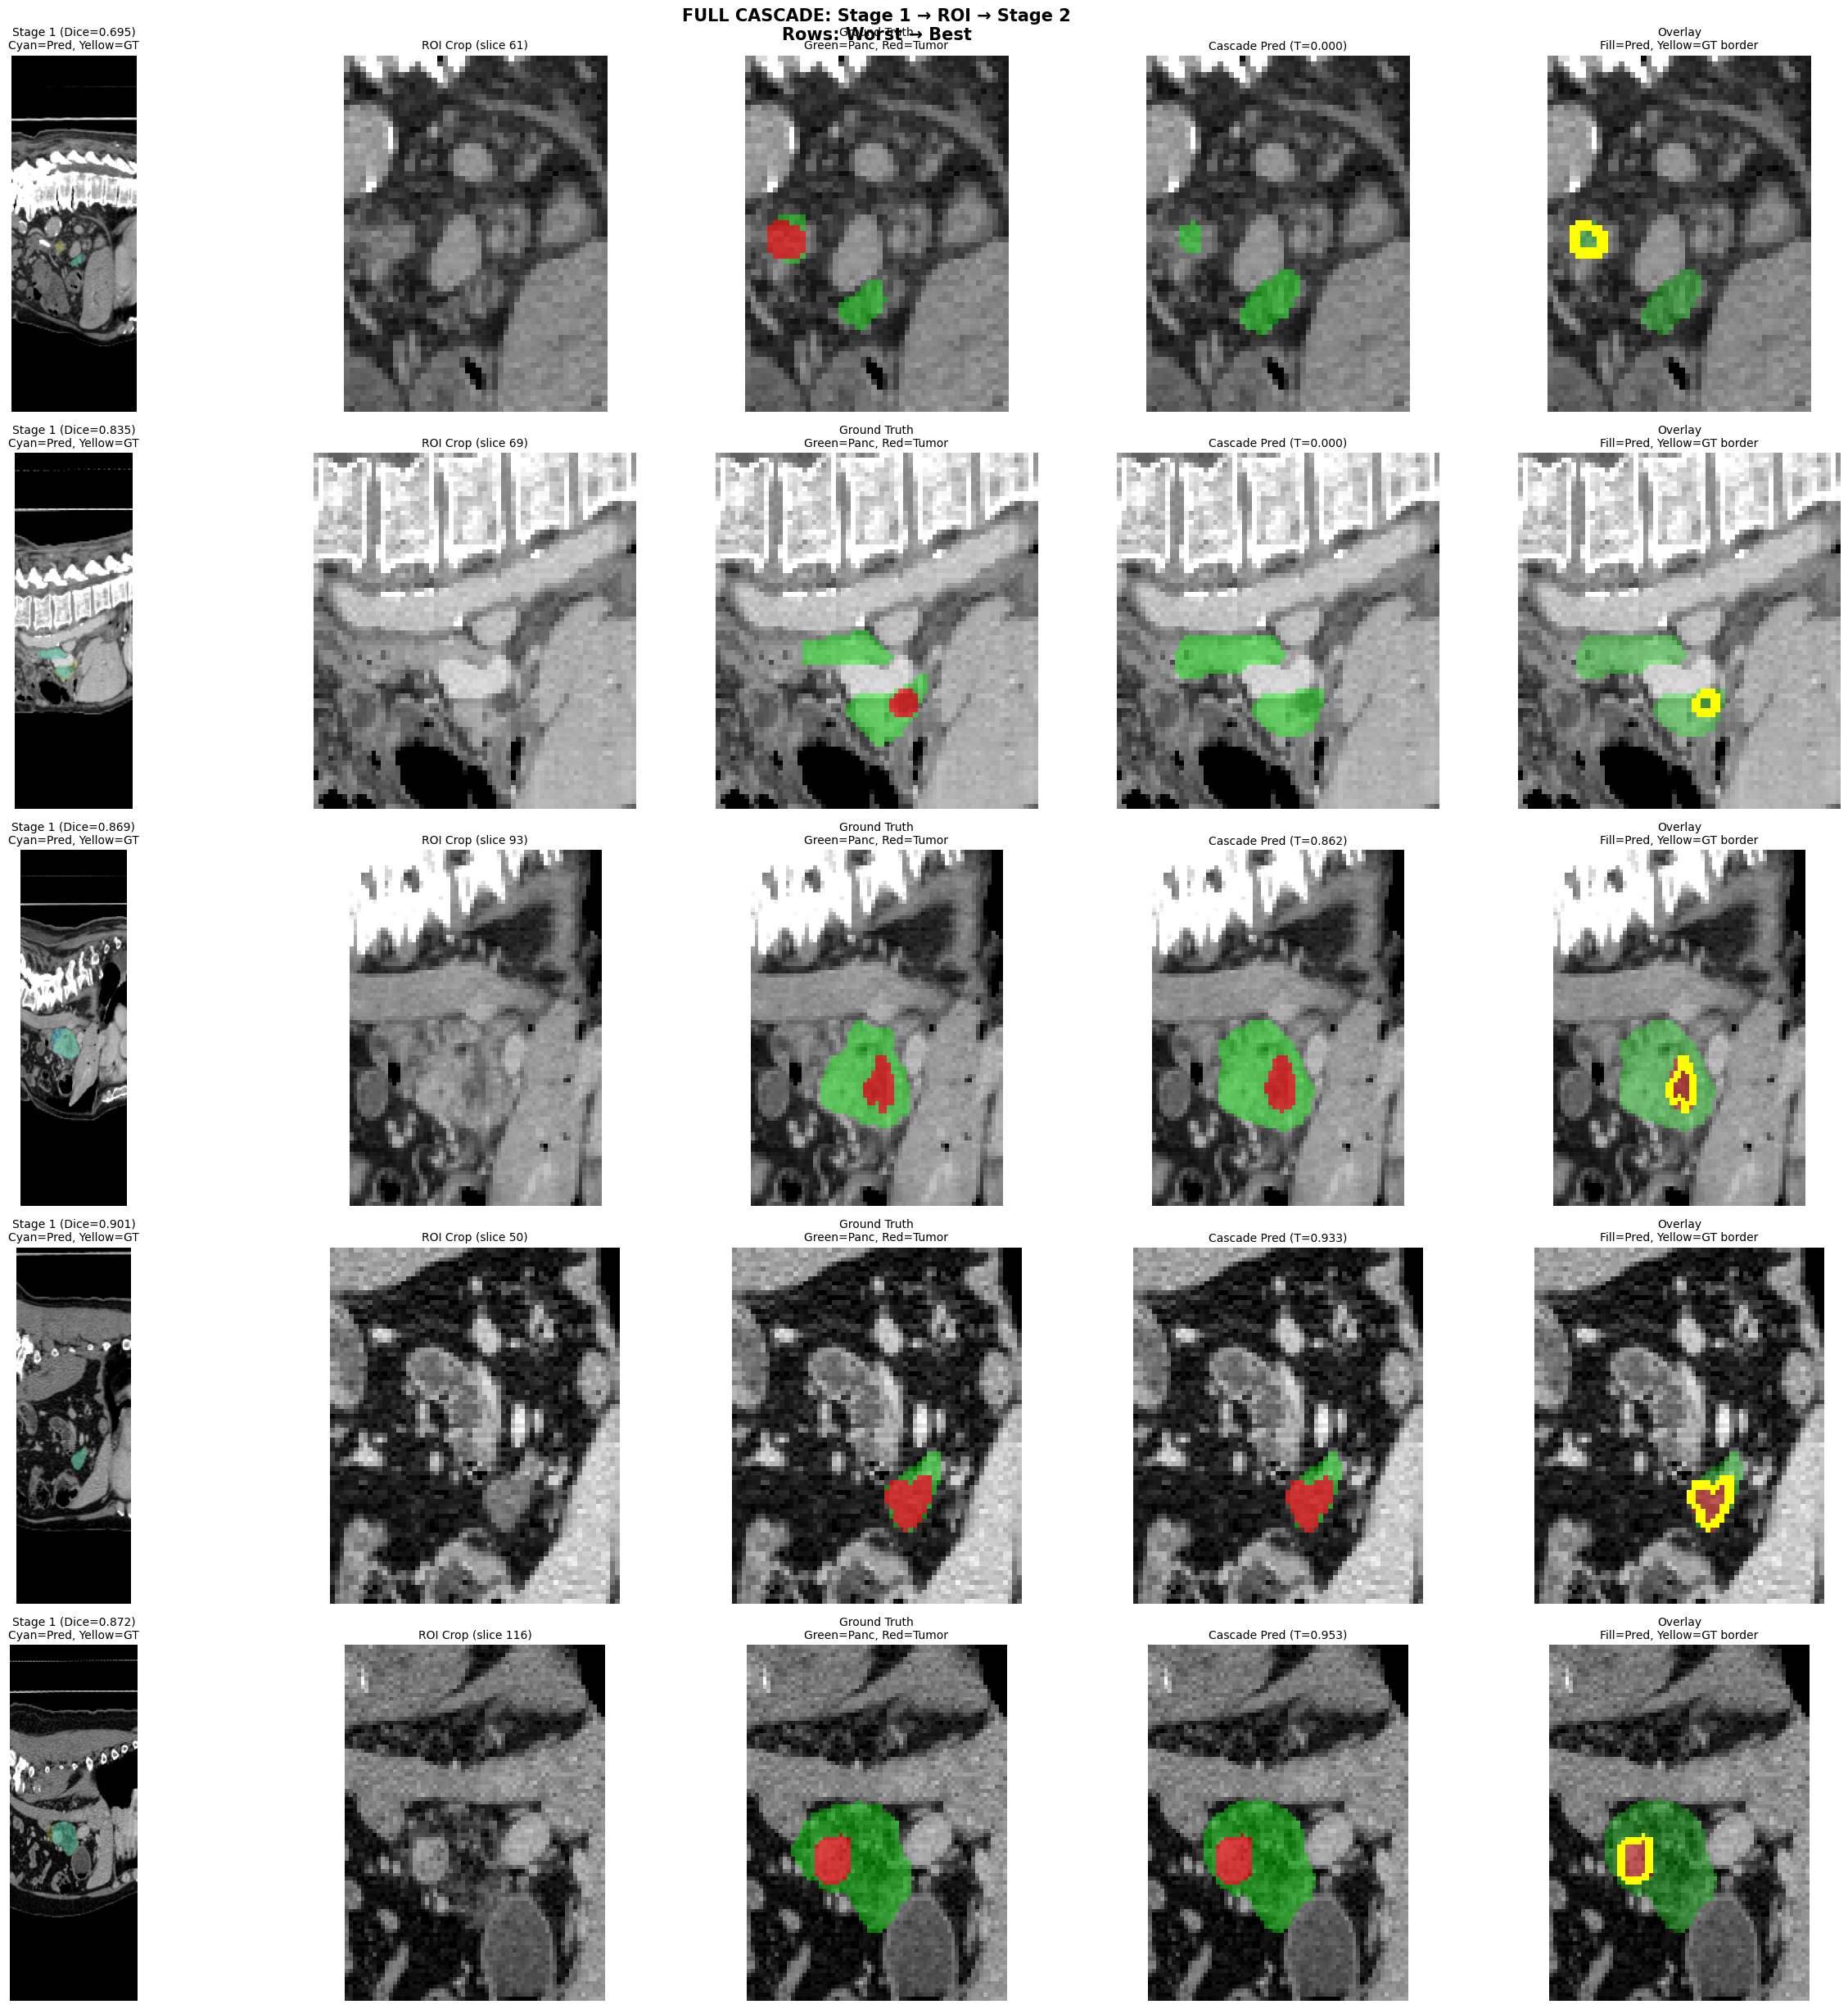

In [7]:
import matplotlib.pyplot as plt

# Pick worst, medium, best cascade cases
case_data = []
for ci in range(len(val_cases)):
    name = os.path.basename(val_cases[ci][0]).replace(".nii.gz","").replace(".nii","")
    case_data.append((ci, name, results['cascade_tumor'][ci], results['s1_panc'][ci]))

case_data.sort(key=lambda x: x[2])

cases_to_show = [
    case_data[0],                    # Worst
    case_data[1],                    # Second worst
    case_data[len(case_data)//2],    # Median
    case_data[-2],                   # Second best
    case_data[-1],                   # Best
]

print("Cases to visualize:")
for idx, name, ct, s1 in cases_to_show:
    print(f"  {name}: S1={s1:.3f}, Cascade Tumor={ct:.3f}")

fig, axes = plt.subplots(len(cases_to_show), 5, figsize=(25, 5*len(cases_to_show)))

for row, (ci, name, cascade_t, s1_d) in enumerate(cases_to_show):
    img_path, lbl_path = val_cases[ci]
    
    # Reload and preprocess
    ct = nib.load(img_path).get_fdata().astype(np.float32)
    gt = nib.load(lbl_path).get_fdata().astype(np.int32)
    spacing = np.array(nib.load(img_path).header.get_zooms()[:3])
    
    scale = spacing / np.array(TARGET_SPACING)
    ct = zoom(ct, scale, order=1)
    gt = zoom(gt, scale, order=0)
    ct = np.clip(ct, HU_WINDOW[0], HU_WINDOW[1])
    fg = gt > 0
    if fg.sum() > 100:
        ct = (ct - ct[fg].mean()) / (ct[fg].std() + 1e-8)
    else:
        ct = (ct - ct.mean()) / (ct.std() + 1e-8)
    
    # Stage 1
    s1_probs = sliding_window_predict(model_s1, ct, (96,96,96), 0.5, 2)
    s1_mask = postprocess_stage1(s1_probs)
    
    # Extract ROI
    ct_roi, gt_roi, bbox, _ = extract_roi(s1_mask, ct, gt, ROI_MARGIN)
    if ct_roi is None:
        print(f"  {name}: Stage 1 failed, skipping visualization")
        continue
    
    # Stage 2 on cascade ROI
    s2_probs = sliding_window_predict(model_s2, ct_roi, (64,64,64), 0.5, 3)
    s2_pred = postprocess_stage2(s2_probs)
    
    # Find slice with most tumor in GT ROI
    tumor_per_slice = [(gt_roi[s] == 2).sum() for s in range(gt_roi.shape[0])]
    mid = np.argmax(tumor_per_slice)
    if max(tumor_per_slice) == 0:
        mid = gt_roi.shape[0] // 2
    
    # Also get full-volume slice for Stage 1 visualization
    s1_slice_idx = bbox[0].start + mid
    s1_slice_idx = min(s1_slice_idx, ct.shape[0]-1)
    
    # Col 1: Full CT slice with Stage 1 overlay
    axes[row, 0].imshow(ct[s1_slice_idx], cmap='gray')
    s1_overlay = np.zeros((*ct[s1_slice_idx].shape, 4))
    s1_overlay[s1_mask[s1_slice_idx] == 1] = [0, 0.8, 1, 0.3]  # Cyan = Stage 1 pancreas
    gt_panc_overlay = np.zeros((*gt[s1_slice_idx].shape, 4))
    gt_panc_overlay[gt[s1_slice_idx] > 0] = [1, 1, 0, 0.2]  # Yellow = GT pancreas outline
    axes[row, 0].imshow(gt_panc_overlay)
    axes[row, 0].imshow(s1_overlay)
    axes[row, 0].set_title(f'Stage 1 (Dice={s1_d:.3f})\nCyan=Pred, Yellow=GT', fontsize=10)
    
    # Col 2: ROI - CT slice
    axes[row, 1].imshow(ct_roi[mid], cmap='gray')
    axes[row, 1].set_title(f'ROI Crop (slice {mid})', fontsize=10)
    
    # Col 3: ROI - Ground Truth
    axes[row, 2].imshow(ct_roi[mid], cmap='gray')
    gt_overlay = np.zeros((*gt_roi[mid].shape, 4))
    gt_overlay[gt_roi[mid] == 1] = [0, 1, 0, 0.4]
    gt_overlay[gt_roi[mid] == 2] = [1, 0, 0, 0.6]
    axes[row, 2].imshow(gt_overlay)
    axes[row, 2].set_title('Ground Truth\nGreen=Panc, Red=Tumor', fontsize=10)
    
    # Col 4: ROI - Cascade Prediction
    axes[row, 3].imshow(ct_roi[mid], cmap='gray')
    pred_overlay = np.zeros((*s2_pred[mid].shape, 4))
    pred_overlay[s2_pred[mid] == 1] = [0, 1, 0, 0.4]
    pred_overlay[s2_pred[mid] == 2] = [1, 0, 0, 0.6]
    axes[row, 3].imshow(pred_overlay)
    ct_t = dice_score(s2_pred, gt_roi, 2)
    axes[row, 3].set_title(f'Cascade Pred (T={ct_t:.3f})', fontsize=10)
    
    # Col 5: Overlay comparison (GT contour + Prediction fill)
    axes[row, 4].imshow(ct_roi[mid], cmap='gray')
    # Prediction as fill
    pred_overlay2 = np.zeros((*s2_pred[mid].shape, 4))
    pred_overlay2[s2_pred[mid] == 1] = [0, 1, 0, 0.3]
    pred_overlay2[s2_pred[mid] == 2] = [1, 0, 0, 0.4]
    axes[row, 4].imshow(pred_overlay2)
    # GT tumor contour in yellow
    from scipy.ndimage import binary_erosion
    gt_tumor_slice = (gt_roi[mid] == 2).astype(np.uint8)
    if gt_tumor_slice.sum() > 0:
        gt_contour = gt_tumor_slice - binary_erosion(gt_tumor_slice, iterations=2).astype(np.uint8)
        contour_overlay = np.zeros((*gt_tumor_slice.shape, 4))
        contour_overlay[gt_contour > 0] = [1, 1, 0, 1.0]
        axes[row, 4].imshow(contour_overlay)
    axes[row, 4].set_title('Overlay\nFill=Pred, Yellow=GT border', fontsize=10)
    
    axes[row, 0].set_ylabel(f'{name}\nCascade T={cascade_t:.3f}', fontsize=11, fontweight='bold')
    
    for ax in axes[row]:
        ax.axis('off')
    
    gc.collect(); torch.cuda.empty_cache()

plt.suptitle('FULL CASCADE: Stage 1 → ROI → Stage 2\nRows: Worst → Best', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/cascade_visual_verification.png', dpi=150, bbox_inches='tight')
plt.show()

  VERIFICATION: 10 TRAINING CASES (model trained on these)

  [TRAIN 1/10] pancreas_366 S1=0.927 Cascade: P=0.908 T=0.918
  [TRAIN 2/10] pancreas_200 S1=0.844 Cascade: P=0.872 T=0.803
  [TRAIN 3/10] pancreas_348 S1=0.842 Cascade: P=0.890 T=0.833
  [TRAIN 4/10] pancreas_377 S1=0.817 Cascade: P=0.583 T=0.886
  [TRAIN 5/10] pancreas_275 S1=0.910 Cascade: P=0.895 T=0.883
  [TRAIN 6/10] pancreas_015 S1=0.905 Cascade: P=0.910 T=0.876
  [TRAIN 7/10] pancreas_369 S1=0.856 Cascade: P=0.888 T=0.941
  [TRAIN 8/10] pancreas_119 S1=0.911 Cascade: P=0.897 T=0.918
  [TRAIN 9/10] pancreas_137 S1=0.882 Cascade: P=0.891 T=0.900
  [TRAIN 10/10] pancreas_096 S1=0.918 Cascade: P=0.911 T=0.943

  STEP-BY-STEP DEBUG: Single case deep inspection

Case: pancreas_064
  Original shape:    (512, 512, 93)
  Original spacing:  [0.894531 0.894531 2.5     ]
  GT classes:        [0 1 2] (0=bg, 1=panc, 2=tumor)
  GT pancreas voxels:52283
  GT tumor voxels:   9042

  After resampling:  (305, 305, 93)
  GT classes:      

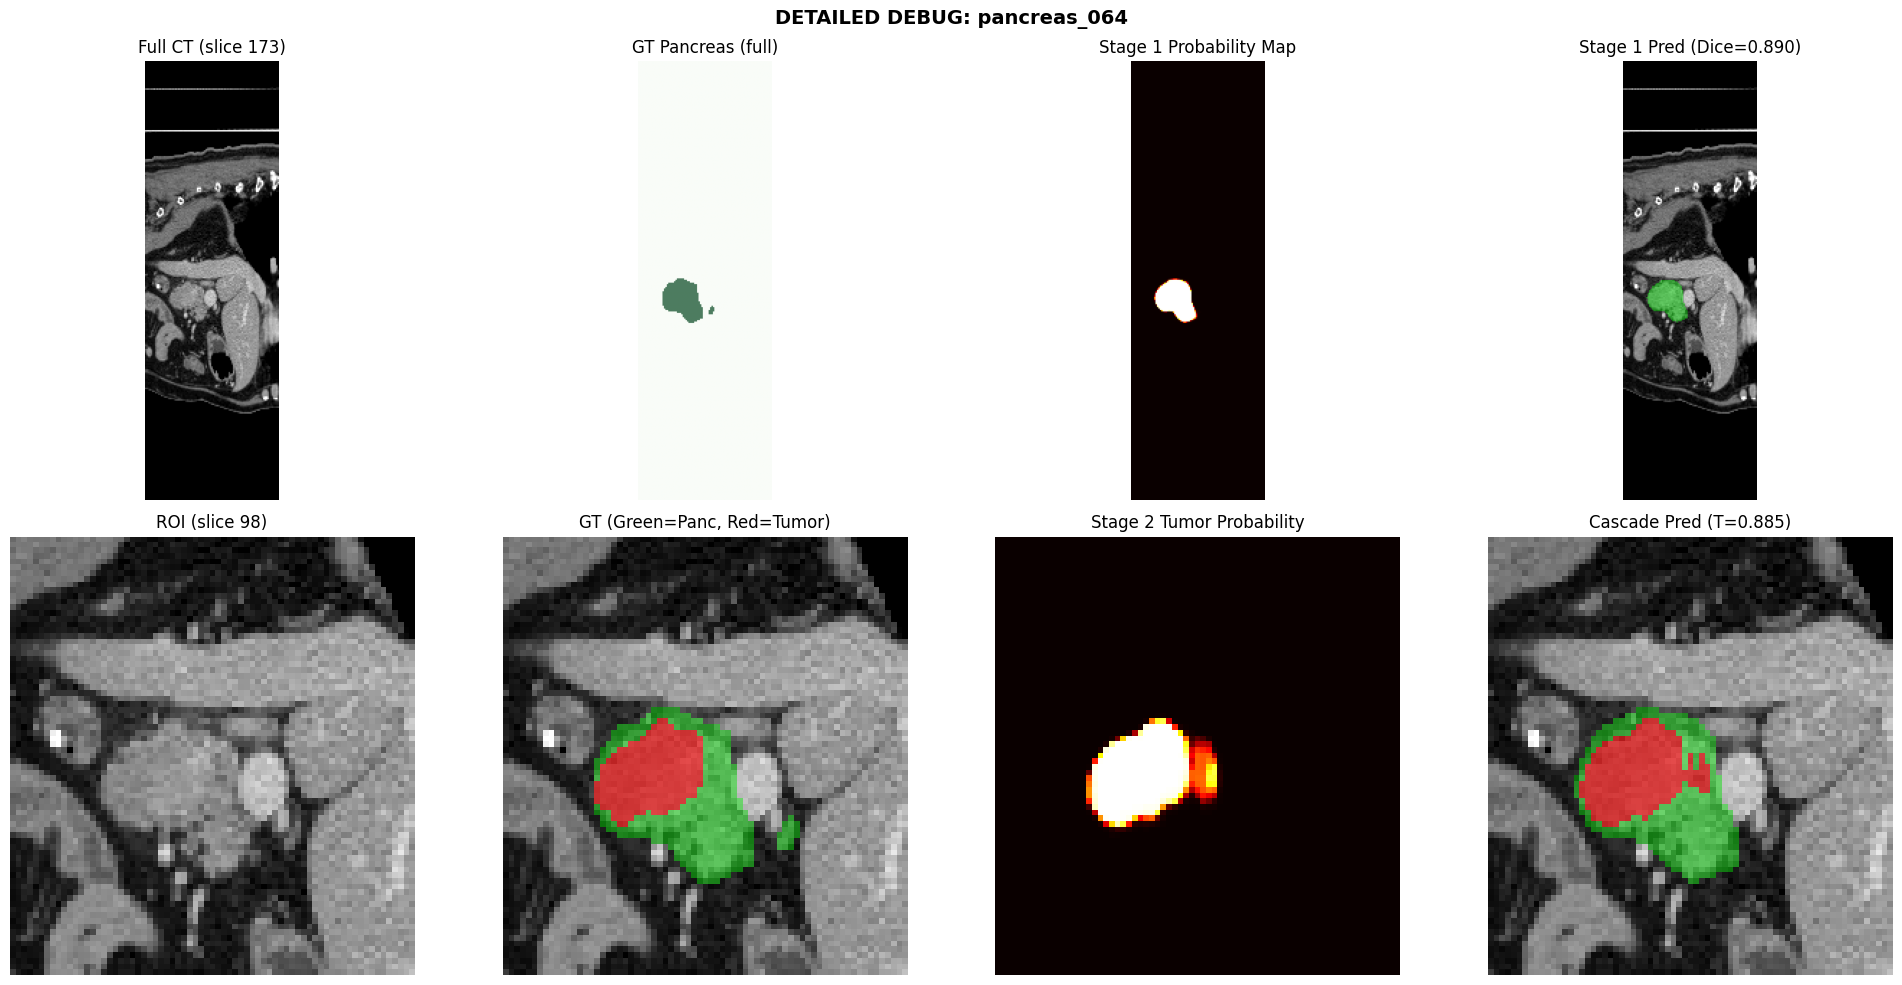

In [12]:
# ============================================================
# VERIFICATION: Test on TRAINING cases (model HAS seen these)
# + Step-by-step debug on one case
# ============================================================

# Get TRAINING cases (different from validation)
np.random.seed(42)
idx = np.random.permutation(len(cases))
val_size = int(len(cases) * 0.15)

train_cases = [cases[i] for i in idx[val_size:]]
test_subset = train_cases[:10]  # First 10 training cases

print(f"{'='*70}")
print(f"  VERIFICATION: 10 TRAINING CASES (model trained on these)")
print(f"{'='*70}\n")

for ci, (img_path, lbl_path) in enumerate(test_subset):
    name = os.path.basename(img_path).replace(".nii.gz","").replace(".nii","")
    
    ct = nib.load(img_path).get_fdata().astype(np.float32)
    gt = nib.load(lbl_path).get_fdata().astype(np.int32)
    spacing = np.array(nib.load(img_path).header.get_zooms()[:3])
    
    scale = spacing / np.array(TARGET_SPACING)
    ct = zoom(ct, scale, order=1)
    gt = zoom(gt, scale, order=0)
    ct = np.clip(ct, HU_WINDOW[0], HU_WINDOW[1])
    fg = gt > 0
    if fg.sum() > 100:
        ct = (ct - ct[fg].mean()) / (ct[fg].std() + 1e-8)
    else:
        ct = (ct - ct.mean()) / (ct.std() + 1e-8)
    
    # Stage 1
    s1_probs = sliding_window_predict(model_s1, ct, (96,96,96), 0.5, 2)
    s1_mask = postprocess_stage1(s1_probs)
    s1_dice = dice_score(s1_mask, (gt > 0).astype(int), 1)
    
    # Cascade
    ct_roi, gt_roi, bbox, _ = extract_roi(s1_mask, ct, gt, ROI_MARGIN)
    if ct_roi is not None:
        s2_probs = sliding_window_predict(model_s2, ct_roi, (64,64,64), 0.5, 3)
        s2_pred = postprocess_stage2(s2_probs)
        ct_t = dice_score(s2_pred, gt_roi, 2)
        ct_p = dice_score(s2_pred, gt_roi, 1)
    else:
        ct_t, ct_p = 0, 0
    
    print(f"  [TRAIN {ci+1}/10] {name} S1={s1_dice:.3f} Cascade: P={ct_p:.3f} T={ct_t:.3f}")

print(f"\n{'='*70}")
print(f"  STEP-BY-STEP DEBUG: Single case deep inspection")
print(f"{'='*70}\n")

# Pick first validation case for detailed debug
img_path, lbl_path = val_cases[0]
name = os.path.basename(img_path).replace(".nii.gz","").replace(".nii","")

ct_raw = nib.load(img_path).get_fdata().astype(np.float32)
gt_raw = nib.load(lbl_path).get_fdata().astype(np.int32)
spacing = np.array(nib.load(img_path).header.get_zooms()[:3])

print(f"Case: {name}")
print(f"  Original shape:    {ct_raw.shape}")
print(f"  Original spacing:  {spacing}")
print(f"  GT classes:        {np.unique(gt_raw)} (0=bg, 1=panc, 2=tumor)")
print(f"  GT pancreas voxels:{(gt_raw==1).sum()}")
print(f"  GT tumor voxels:   {(gt_raw==2).sum()}")

scale = spacing / np.array(TARGET_SPACING)
ct = zoom(ct_raw, scale, order=1)
gt = zoom(gt_raw, scale, order=0)
ct = np.clip(ct, HU_WINDOW[0], HU_WINDOW[1])
fg = gt > 0
ct = (ct - ct[fg].mean()) / (ct[fg].std() + 1e-8)

print(f"\n  After resampling:  {ct.shape}")
print(f"  GT classes:        {np.unique(gt)}")
print(f"  GT pancreas voxels:{(gt==1).sum()}")
print(f"  GT tumor voxels:   {(gt==2).sum()}")

# Stage 1 detailed
print(f"\n  --- Stage 1 ---")
s1_probs = sliding_window_predict(model_s1, ct, (96,96,96), 0.5, 2)
print(f"  Prob map shape:    {s1_probs.shape}")
print(f"  Prob range:        [{s1_probs.min():.4f}, {s1_probs.max():.4f}]")
print(f"  Panc prob mean:    {s1_probs[1].mean():.4f}")
print(f"  Panc prob max:     {s1_probs[1].max():.4f}")

s1_raw = s1_probs.argmax(0)
print(f"  Raw pred classes:  {np.unique(s1_raw)}")
print(f"  Raw pred panc vox: {(s1_raw==1).sum()}")

s1_mask = postprocess_stage1(s1_probs)
print(f"  PP pred panc vox:  {(s1_mask==1).sum()}")
s1_dice = dice_score(s1_mask, (gt > 0).astype(int), 1)
print(f"  Stage 1 Dice:      {s1_dice:.4f}")

# ROI extraction
ct_roi, gt_roi, bbox, _ = extract_roi(s1_mask, ct, gt, ROI_MARGIN)
print(f"\n  --- ROI Extraction ---")
print(f"  ROI shape:         {ct_roi.shape}")
print(f"  GT pancreas in ROI:{(gt_roi==1).sum()}")
print(f"  GT tumor in ROI:   {(gt_roi==2).sum()}")
gt_total = (gt > 0).sum()
gt_in_roi = (gt_roi > 0).sum()
print(f"  ROI recall:        {gt_in_roi/gt_total:.4f}")

# Stage 2 detailed
print(f"\n  --- Stage 2 ---")
s2_probs = sliding_window_predict(model_s2, ct_roi, (64,64,64), 0.5, 3)
print(f"  Prob map shape:    {s2_probs.shape}")
print(f"  Class 0 (bg) mean: {s2_probs[0].mean():.4f}")
print(f"  Class 1 (panc) mn: {s2_probs[1].mean():.4f}")
print(f"  Class 2 (tumor) mn:{s2_probs[2].mean():.4f}")

s2_raw = s2_probs.argmax(0)
print(f"  Raw pred classes:  {np.unique(s2_raw)}")
print(f"  Raw panc voxels:   {(s2_raw==1).sum()}")
print(f"  Raw tumor voxels:  {(s2_raw==2).sum()}")

s2_pred = postprocess_stage2(s2_probs)
print(f"  PP panc voxels:    {(s2_pred==1).sum()}")
print(f"  PP tumor voxels:   {(s2_pred==2).sum()}")

ct_p = dice_score(s2_pred, gt_roi, 1)
ct_t = dice_score(s2_pred, gt_roi, 2)
print(f"\n  Final Cascade Dice:")
print(f"    Pancreas:        {ct_p:.4f}")
print(f"    Tumor:           {ct_t:.4f}")

# Visualize this single case in detail
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Find best tumor slice
tumor_slices = [(gt_roi[s]==2).sum() for s in range(gt_roi.shape[0])]
mid = np.argmax(tumor_slices)

# Row 1: Stage 1 (full volume)
s1_full_slice = bbox[0].start + mid
s1_full_slice = min(s1_full_slice, ct.shape[0]-1)

axes[0,0].imshow(ct[s1_full_slice], cmap='gray')
axes[0,0].set_title(f'Full CT (slice {s1_full_slice})')

axes[0,1].imshow(gt[s1_full_slice] > 0, cmap='Greens', alpha=0.7)
axes[0,1].set_title('GT Pancreas (full)')

axes[0,2].imshow(s1_probs[1, s1_full_slice], cmap='hot', vmin=0, vmax=1)
axes[0,2].set_title('Stage 1 Probability Map')

axes[0,3].imshow(ct[s1_full_slice], cmap='gray')
s1_ov = np.zeros((*s1_mask[s1_full_slice].shape, 4))
s1_ov[s1_mask[s1_full_slice]==1] = [0,1,0,0.4]
axes[0,3].imshow(s1_ov)
axes[0,3].set_title(f'Stage 1 Pred (Dice={s1_dice:.3f})')

# Row 2: Stage 2 (ROI)
axes[1,0].imshow(ct_roi[mid], cmap='gray')
axes[1,0].set_title(f'ROI (slice {mid})')

gt_ov = np.zeros((*gt_roi[mid].shape, 4))
gt_ov[gt_roi[mid]==1] = [0,1,0,0.4]
gt_ov[gt_roi[mid]==2] = [1,0,0,0.6]
axes[1,1].imshow(ct_roi[mid], cmap='gray')
axes[1,1].imshow(gt_ov)
axes[1,1].set_title('GT (Green=Panc, Red=Tumor)')

axes[1,2].imshow(s2_probs[2, mid], cmap='hot', vmin=0, vmax=1)
axes[1,2].set_title('Stage 2 Tumor Probability')

pred_ov = np.zeros((*s2_pred[mid].shape, 4))
pred_ov[s2_pred[mid]==1] = [0,1,0,0.4]
pred_ov[s2_pred[mid]==2] = [1,0,0,0.6]
axes[1,3].imshow(ct_roi[mid], cmap='gray')
axes[1,3].imshow(pred_ov)
axes[1,3].set_title(f'Cascade Pred (T={ct_t:.3f})')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle(f'DETAILED DEBUG: {name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/debug_verification.png', dpi=150)
plt.show()